In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

from common.dsp import bandpass_filter, compute_fft
from scipy.signal import hilbert, butter, lfilter
from common.config import bearing_fault_frequencies, NOMINAL_RPM_BY_LOAD

In [9]:
OUTPUT_DIR = Path("./outputs")
TABLES_DIR = OUTPUT_DIR / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

manifest = pd.read_csv(TABLES_DIR / "manifest_filtered.csv")

In [33]:
# Tạm lấy một file Lỗi vòng ngoài (OR) ở Tải 2 HP làm ví dụ
ir_load2_files = manifest[(manifest['label'] == 'IR') & (manifest['load_hp'] == 1)]
file_path = ir_load2_files.iloc[0]['file_path']

# 2. Load tín hiệu 
import common.io_utils as io_utils
x_full = io_utils.load_de_signal(Path(file_path))

# Cắt 4000 mẫu đầu tiên để quan sát miền thời gian cho rõ
x = x_full[:4000]
fs = 12000
rpm = NOMINAL_RPM_BY_LOAD[2]
fault_freqs = bearing_fault_frequencies(rpm)
bpfo_hz = fault_freqs["BPFO"]

print(f"Đã load file: {file_path}")
print(f"Tần số lấy mẫu: {fs} Hz | BPFO lý thuyết: {bpfo_hz:.2f} Hz")

Đã load file: ..\..\data\raw\12k_Drive_End_Bearing_Fault_Data\IR\007\106_1.mat
Tần số lấy mẫu: 12000 Hz | BPFO lý thuyết: 104.56 Hz


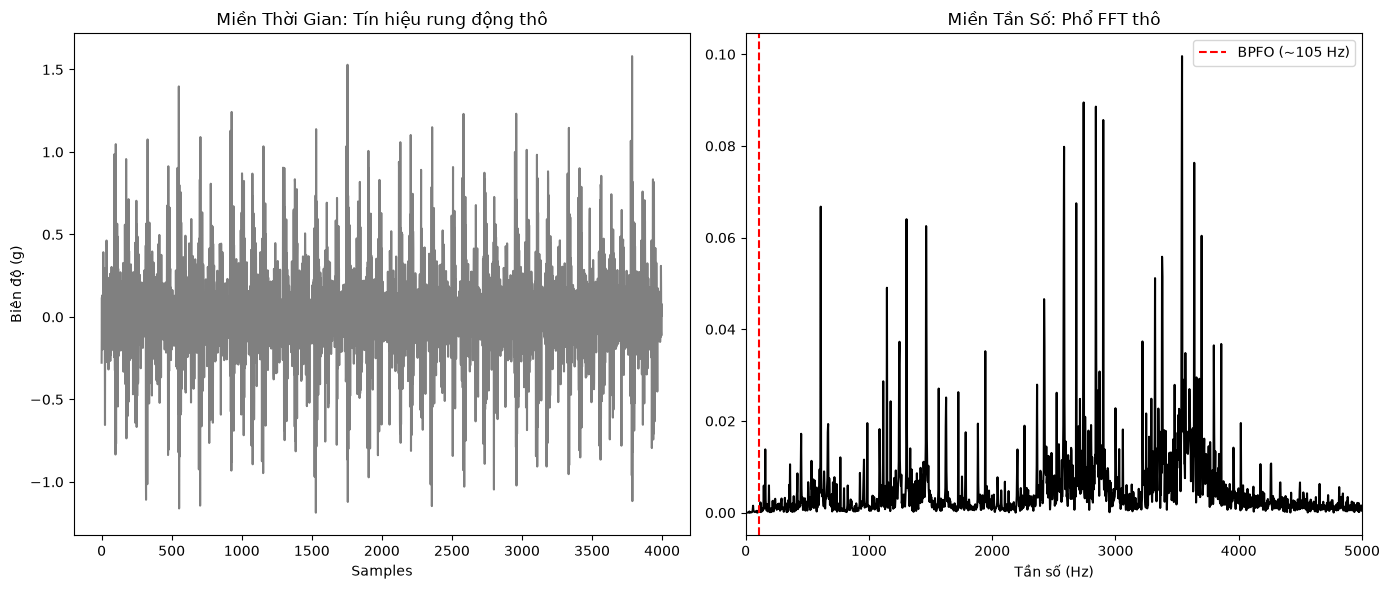

In [34]:
# Tính FFT của tín hiệu thô
freqs_raw, mag_raw = compute_fft(x - np.mean(x), fs)

plt.figure(figsize=(14, 6))

# Tín hiệu miền thời gian thô
plt.subplot(1, 2, 1)
plt.plot(x, color='gray')
plt.title("Miền Thời Gian: Tín hiệu rung động thô")
plt.xlabel("Samples")
plt.ylabel("Biên độ (g)")

# Phổ tần số thô
plt.subplot(1, 2, 2)
plt.plot(freqs_raw, mag_raw, color='black')
plt.axvline(bpfo_hz, color='red', linestyle='--', label='BPFO (~105 Hz)')
plt.xlim(0, 5000)
plt.title("Miền Tần Số: Phổ FFT thô")
plt.xlabel("Tần số (Hz)")
plt.legend()

plt.tight_layout()
plt.show()

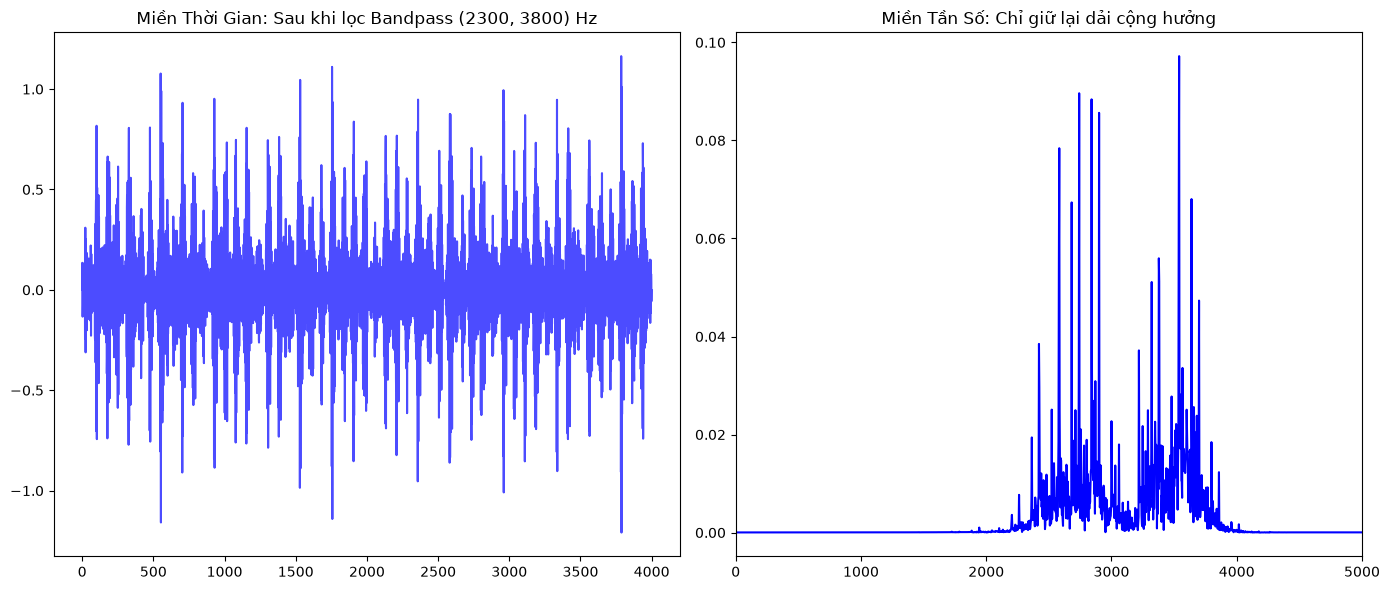

In [35]:
BAND_HZ = (2300, 3800) # Dải cộng hưởng chuẩn của động cơ CWRU

# Ép kiểu asarray để Pylance không báo lỗi
x_bp = np.asarray(bandpass_filter(x, fs, low_hz=BAND_HZ[0], high_hz=BAND_HZ[1], order=4))

freqs_bp, mag_bp = compute_fft(x_bp, fs)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(x_bp, color='blue', alpha=0.7)
plt.title(f"Miền Thời Gian: Sau khi lọc Bandpass {BAND_HZ} Hz")

plt.subplot(1, 2, 2)
plt.plot(freqs_bp, mag_bp, color='blue')
plt.xlim(0, 5000)
plt.title("Miền Tần Số: Chỉ giữ lại dải cộng hưởng")

plt.tight_layout()
plt.show()

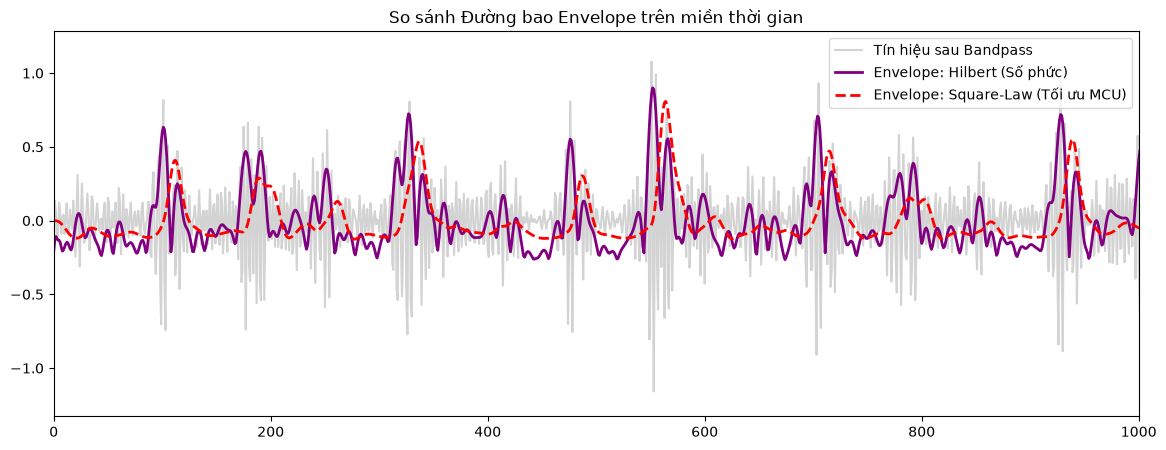

In [32]:
# --- NHÁNH 1: HILBERT TRANSFORM ---
analytic_signal = hilbert(x_bp)
env_hilbert = np.abs(analytic_signal)
env_hilbert_ac = env_hilbert - np.mean(env_hilbert) # Khử DC để vẽ FFT không bị lệch

# --- NHÁNH 2: SQUARE-LAW ĐÃ TỐI ƯU ---
x_sq = x_bp ** 2
x_sq_ac = x_sq - np.mean(x_sq)

# Lọc Lowpass
nyq = 0.5 * fs
b_lp, a_lp = butter(4, 500 / nyq, btype='lowpass') # type: ignore
env_square = np.asarray(lfilter(b_lp, a_lp, x_sq_ac))
env_square_ac = env_square - np.mean(env_square)

# Vẽ đồ thị so sánh miền thời gian
plt.figure(figsize=(14, 5))
plt.plot(x_bp, color='lightgray', label='Tín hiệu sau Bandpass')
plt.plot(env_hilbert_ac, color='purple', linewidth=2, label='Envelope: Hilbert (Số phức)')
plt.plot(env_square_ac * 2, color='red', linestyle='--', linewidth=2, label='Envelope: Square-Law (Tối ưu MCU)')
plt.title("So sánh Đường bao Envelope trên miền thời gian")
plt.legend(loc="upper right")
plt.xlim(0, 1000)
plt.show()

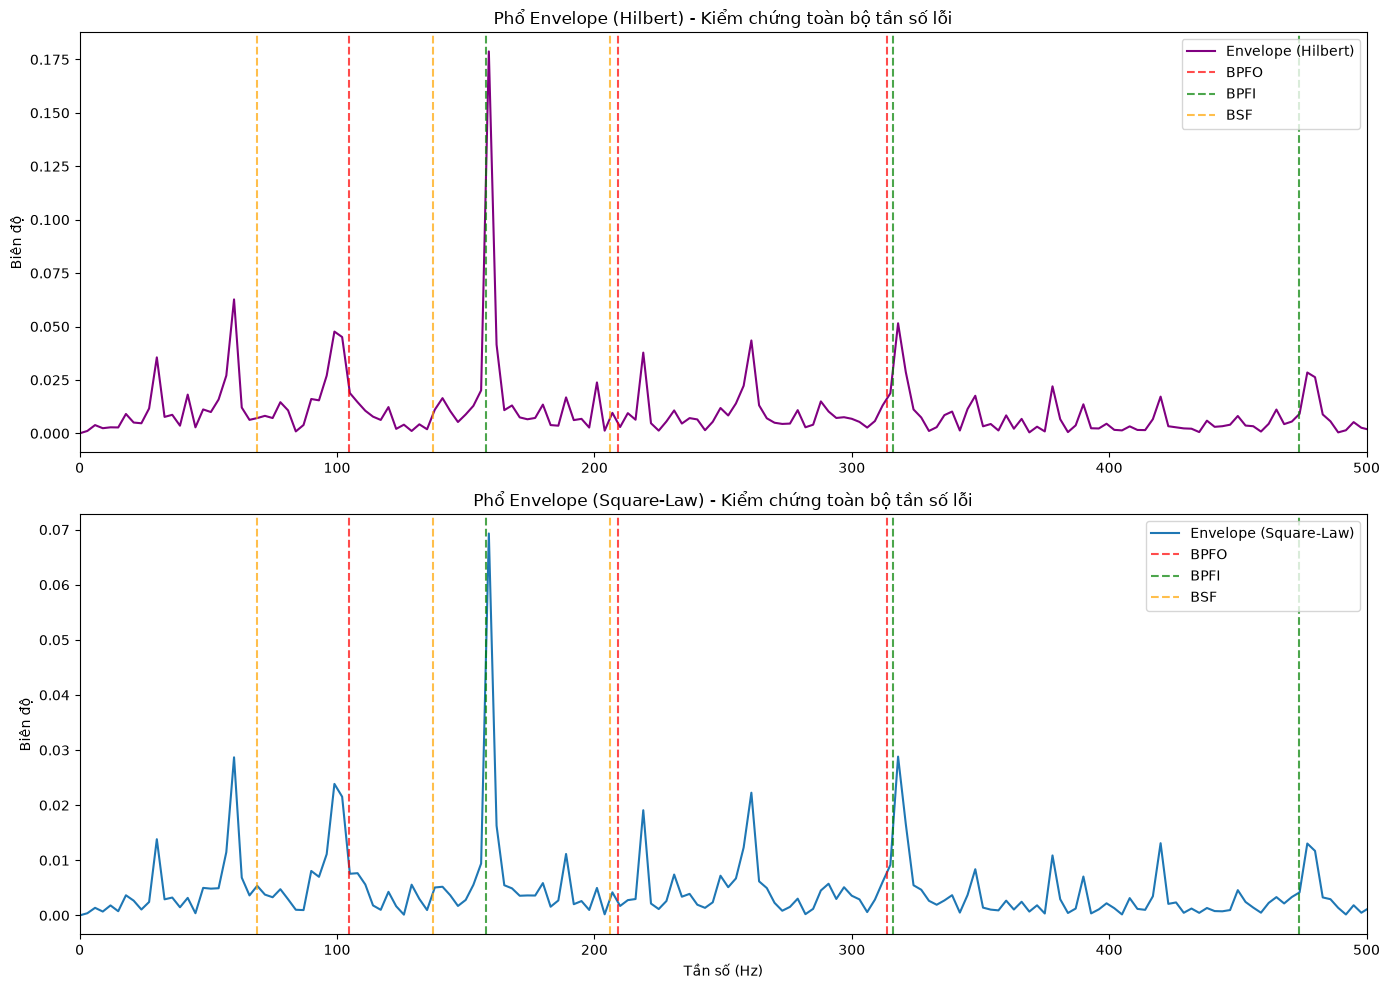

In [37]:
# Phân tích FFT cho cả 2 đường bao
freqs_h, mag_h = compute_fft(env_hilbert_ac, fs)
freqs_s, mag_s = compute_fft(env_square_ac, fs)

plt.figure(figsize=(14, 10))

# 1. Định nghĩa màu sắc cho các loại tần số lỗi
color_map = {
    "BPFO": "red",     # Lỗi vòng ngoài (Outer Race)
    "BPFI": "green",   # Lỗi vòng trong (Inner Race)
    "BSF": "orange"    # Lỗi con lăn (Ball Spin) - dùng màu cam để không trùng màu tím của Hilbert
}

# ==========================================
# Đồ thị 1: Phổ của Hilbert
# ==========================================
plt.subplot(2, 1, 1)
plt.plot(freqs_h, mag_h, color='purple', label='Envelope (Hilbert)')

# Vẽ toàn bộ vạch tần số lỗi
for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        # Chỉ gán label ở sóng hài bậc 1 để bảng chú thích không bị lặp
        label_name = f"{name}" if h == 1 else None
        plt.axvline(fault_freqs[name] * h, color=color_map[name], linestyle='--', alpha=0.7, label=label_name)

plt.xlim(0, 500)
plt.title("Phổ Envelope (Hilbert) - Kiểm chứng toàn bộ tần số lỗi")
plt.ylabel("Biên độ")
plt.legend(loc="upper right")


# ==========================================
# Đồ thị 2: Phổ của Square-Law
# ==========================================
plt.subplot(2, 1, 2)
# Đổi màu xanh dương cho Square-law để dễ nhìn các vạch màu
plt.plot(freqs_s, mag_s, color='#1f77b4', label='Envelope (Square-Law)') 

# Vẽ toàn bộ vạch tần số lỗi
for name in ["BPFO", "BPFI", "BSF"]:
    for h in [1, 2, 3]:
        label_name = f"{name}" if h == 1 else None
        plt.axvline(fault_freqs[name] * h, color=color_map[name], linestyle='--', alpha=0.7, label=label_name)

plt.xlim(0, 500)
plt.title("Phổ Envelope (Square-Law) - Kiểm chứng toàn bộ tần số lỗi")
plt.xlabel("Tần số (Hz)")
plt.ylabel("Biên độ")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()